# Hidden Markov Models (HMMs) and Viterbi Algorithm

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand Hidden Markov Models (HMMs) structure and components
- Implement HMMs for sequence prediction
- Implement Viterbi algorithm for sequence decoding
- Apply HMMs to a practical problem on **real text**: recovering a real sentence that has
  been corrupted by a noisy keyboard

## 🔗 Where this fits

**Builds on:** Course 02 — Unit 3, lesson 02 "Bayesian Networks" — the same conditional-independence graph, unrolled over time so the hidden state moves.

**Used later in:** Course 07 (AIAT 121) — Unit 3, whose POS-tagging and NER task is this same sequence-labelling problem, solved with a modern tagger instead of Viterbi.

---

This notebook covers practical activities from **Course 02, Unit 3**:
- Working with Hidden Markov Models (HMMs) for sequence prediction
- Implementing Viterbi algorithm for sequence decoding
- Applying HMMs to practical problems (speech recognition, POS tagging, noisy-channel decoding)

---

## Introduction to Hidden Markov Models

**Hidden Markov Models (HMMs)** are statistical models for sequences where:
- **Hidden states**: Unobserved states (e.g., weather: Sunny, Rainy)
- **Observations**: Observed outputs (e.g., activities: Walk, Shop, Clean)
- **Transitions**: Probabilities between hidden states
- **Emissions**: Probabilities of observations given states


## 🌍 The case: the algorithm that brought back the pictures of Jupiter

Andrew Viterbi published his decoding algorithm in 1967 (reference 1 below) for a communications problem, not for weather or grammar. Three places it has been doing real work ever since:

**Deep space.** The Voyager probes transmitted using a rate-1/2, constraint-length-7 convolutional code, decoded on the ground with the Viterbi algorithm — the same max-and-backpointer recursion you will write in Part 3. NASA's Deep Space Network later built a dedicated **Big Viterbi Decoder** for the Galileo and Cassini missions, handling a constraint-length-15 code and buying roughly another 1.5 dB of coding gain. Photographs taken a billion kilometres away arrive as a noisy bit stream; Viterbi decoding is what turns it back into an image.

**Speech, 1980s to roughly 2010.** Every commercial speech recogniser of that era was a hidden Markov model decoded with Viterbi: hidden states are the phonemes actually spoken, observations are the acoustic frames actually measured. Rabiner's 1989 tutorial (reference 2) is the paper that trained the industry, and it is still the clearest description of the three problems you will solve below.

**Biology.** The **Pfam** database gives each protein family a *profile HMM*, built with **HMMER** (Eddy, *Profile hidden Markov models*, Bioinformatics 14, 755–763, 1998). Asking which family a newly sequenced protein belongs to is a forward or Viterbi computation over hidden states — the same code, with amino acids instead of letters.

### What goes wrong without this

Part 4 corrupts a real sentence with a faulty keyboard and leaves it **74.0% correct**. Now try to repair it one character at a time. You cannot: for a key that has slipped, every adjacent key is an equally good guess, and looking at that single character gives you nothing to choose with. Independent decisions on independent characters cannot beat the channel.

What breaks the tie is *context* — the fact that in English `q` is almost always followed by `u` (over 99% of the word-list bigrams beginning with `q` are `qu`; the smoothed estimate this notebook measures from its own corpus is 0.81), that `th` is common and `xh` is not. A hidden Markov model is the smallest honest way to write that down, and Viterbi is how you use it to pick the best **whole sequence** rather than the best individual guesses. Without a model of what sequences are plausible, the errors are permanent.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np

print("✅ Libraries imported!")
print("Ready to work with HMMs and Viterbi algorithm!")


✅ Libraries imported!
Ready to work with HMMs and Viterbi algorithm!


## Part 0: A 60-Second Markov Chain Primer

An HMM is built on a **Markov chain**, so let's meet that idea first.

A Markov chain is a system that hops between **states** (e.g., Sunny / Rainy), where the probability of the next state depends ONLY on the current state — not on the full history. This is the **Markov property** ("memorylessness").

Its entire behavior is captured by a **transition matrix**: one row per current state, giving the probability of each next state (every row sums to 1).

The simulation below shows two things:
1. A sampled sequence of weather states (each day generated only from the previous day).
2. The long-run fraction of days spent in each state settles to fixed values determined by the transition matrix alone.

An HMM then adds one twist: you cannot see the states themselves — only noisy **observations** emitted from them.

In [2]:
# A tiny 2-state Markov chain: tomorrow's weather depends only on today's
np.random.seed(42)  # Reproducible simulation

# Transition matrix: P[current][next]  (each row sums to 1)
P = {
    'Sunny': {'Sunny': 0.7, 'Rainy': 0.3},
    'Rainy': {'Sunny': 0.4, 'Rainy': 0.6}
}

# Simulate 10,000 days, starting Sunny
states_list = ['Sunny', 'Rainy']
day, chain = 'Sunny', ['Sunny']
for _ in range(9999):
    probs = [P[day][s] for s in states_list]
    day = np.random.choice(states_list, p=probs)
    chain.append(day)

print("First 15 simulated days:")
print("  " + " -> ".join(s[0] for s in chain[:15]) + "   (S=Sunny, R=Rainy)")
print()

# Long-run fraction of time in each state (empirical)
frac_sunny = chain.count('Sunny') / len(chain)
frac_rainy = chain.count('Rainy') / len(chain)

# Theoretical long-run (stationary) fractions for a 2-state chain:
# pi_Sunny = P(R->S) / (P(S->R) + P(R->S))
pi_sunny = P['Rainy']['Sunny'] / (P['Sunny']['Rainy'] + P['Rainy']['Sunny'])
pi_rainy = 1 - pi_sunny

print(f"Long-run fraction of days (10,000-day simulation vs. theory):")
print(f"  Sunny: {frac_sunny:.3f}  (theory: {pi_sunny:.3f})")
print(f"  Rainy: {frac_rainy:.3f}  (theory: {pi_rainy:.3f})")
print()
print("Key point: the transition matrix alone controls the chain's behavior.")
print("Next: an HMM uses exactly this kind of chain for its HIDDEN states.")

First 15 simulated days:
  S -> S -> R -> R -> R -> S -> S -> S -> R -> R -> R -> S -> R -> R -> S   (S=Sunny, R=Rainy)

Long-run fraction of days (10,000-day simulation vs. theory):
  Sunny: 0.586  (theory: 0.571)
  Rainy: 0.414  (theory: 0.429)

Key point: the transition matrix alone controls the chain's behavior.
Next: an HMM uses exactly this kind of chain for its HIDDEN states.


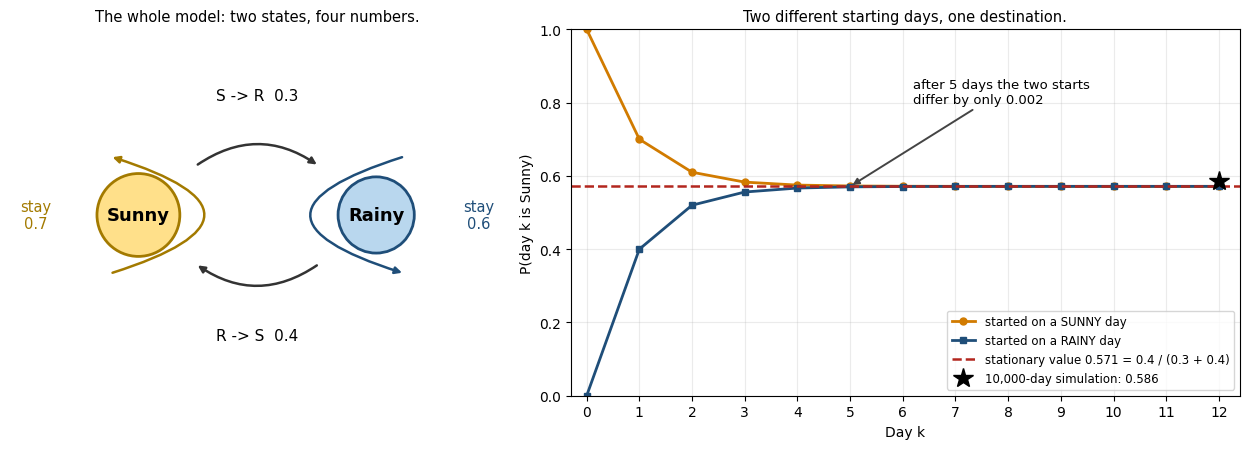

 day k   start Sunny   start Rainy       gap
     0        1.0000        0.0000    1.0000
     1        0.7000        0.4000    0.3000
     2        0.6100        0.5200    0.0900
     3        0.5830        0.5560    0.0270
     5        0.5725        0.5700    0.0024
     8        0.5715        0.5714    0.0001
    12        0.5714        0.5714    0.0000

Stationary value (exact): 0.5714. 10,000-day simulation above: 0.5862.


In [3]:
# SEE the chain, and SEE it forget where it started.
# WHAT: left = the 2-state chain drawn as a graph, with the four transition probabilities
#       on their arrows. right = P(day k is Sunny), computed EXACTLY by matrix powers,
#       for two different starting days.
# WHY:  the cell above printed one long-run number. The claim underneath it - "the
#       transition matrix alone controls the chain's behaviour" - is a claim about
#       FORGETTING: whatever day you start on, the chain converges to the same place.
#       That is a statement about a trajectory, and only a trajectory can show it.
import matplotlib.pyplot as plt

# The same transition matrix as the dict above, as an array so we can take powers of it.
# Row = today, column = tomorrow, in the order [Sunny, Rainy].
Pm = np.array([[P['Sunny']['Sunny'], P['Sunny']['Rainy']],
               [P['Rainy']['Sunny'], P['Rainy']['Rainy']]])

K = 12
days = np.arange(K + 1)
from_sunny = np.zeros(K + 1)   # P(day k = Sunny) if day 0 was Sunny
from_rainy = np.zeros(K + 1)   # P(day k = Sunny) if day 0 was Rainy
v_s, v_r = np.array([1.0, 0.0]), np.array([0.0, 1.0])
for k in range(K + 1):
    from_sunny[k], from_rainy[k] = v_s[0], v_r[0]
    v_s, v_r = v_s @ Pm, v_r @ Pm

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6),
                         gridspec_kw={"width_ratios": [0.85, 1.15]})

# --- Left: the chain itself ---------------------------------------------------
ax = axes[0]
ax.text(0.25, 0.5, "Sunny", ha="center", va="center", fontsize=13, weight="bold",
        bbox=dict(boxstyle="circle,pad=0.55", fc="#ffe08a", ec="#a37a00", lw=2))
ax.text(0.75, 0.5, "Rainy", ha="center", va="center", fontsize=13, weight="bold",
        bbox=dict(boxstyle="circle,pad=0.55", fc="#b9d7ee", ec="#1f4e79", lw=2))
ax.annotate("", xy=(0.63, 0.60), xytext=(0.37, 0.60),
            arrowprops=dict(arrowstyle="-|>", color="#333", lw=1.8,
                            connectionstyle="arc3,rad=-0.35"))
ax.annotate("", xy=(0.37, 0.40), xytext=(0.63, 0.40),
            arrowprops=dict(arrowstyle="-|>", color="#333", lw=1.8,
                            connectionstyle="arc3,rad=-0.35"))
ax.text(0.50, 0.735, f"S -> R  {Pm[0,1]:.1f}", ha="center", fontsize=11)
ax.text(0.50, 0.245, f"R -> S  {Pm[1,0]:.1f}", ha="center", fontsize=11)
ax.annotate("", xy=(0.19, 0.62), xytext=(0.19, 0.38),
            arrowprops=dict(arrowstyle="-|>", color="#a37a00", lw=1.8,
                            connectionstyle="arc3,rad=1.6"))
ax.text(0.035, 0.5, f"stay\n{Pm[0,0]:.1f}", ha="center", va="center",
        fontsize=10.5, color="#a37a00")
ax.annotate("", xy=(0.81, 0.38), xytext=(0.81, 0.62),
            arrowprops=dict(arrowstyle="-|>", color="#1f4e79", lw=1.8,
                            connectionstyle="arc3,rad=1.6"))
ax.text(0.965, 0.5, f"stay\n{Pm[1,1]:.1f}", ha="center", va="center",
        fontsize=10.5, color="#1f4e79")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0.13, 0.88); ax.axis("off")
ax.set_title("The whole model: two states, four numbers.", fontsize=10.5)

# --- Right: the chain forgetting its start -----------------------------------
ax = axes[1]
ax.plot(days, from_sunny, "o-", color="#d17b00", lw=2, ms=5,
        label="started on a SUNNY day")
ax.plot(days, from_rainy, "s-", color="#1f4e79", lw=2, ms=5,
        label="started on a RAINY day")
ax.axhline(pi_sunny, color="#b3261e", ls="--", lw=1.8,
           label=f"stationary value {pi_sunny:.3f} = 0.4 / (0.3 + 0.4)")
ax.plot([K], [frac_sunny], "*", color="black", ms=15, zorder=6,
        label=f"10,000-day simulation: {frac_sunny:.3f}")
gap5 = abs(from_sunny[5] - from_rainy[5])
ax.annotate(f"after 5 days the two starts\ndiffer by only {gap5:.3f}",
            xy=(5, (from_sunny[5] + from_rainy[5]) / 2), xytext=(6.2, 0.80),
            fontsize=9.5, arrowprops=dict(arrowstyle="-|>", color="#444", lw=1.4))
ax.set_xlabel("Day k")
ax.set_ylabel("P(day k is Sunny)")
ax.set_ylim(0, 1.0); ax.set_xlim(-0.3, K + 0.4)
ax.set_xticks(days)
ax.set_title("Two different starting days, one destination.", fontsize=10.5)
ax.set_axisbelow(True); ax.grid(alpha=0.25)
ax.legend(loc="lower right", fontsize=8.5)

fig.tight_layout()
plt.show()

print(f"{'day k':>6}{'start Sunny':>14}{'start Rainy':>14}{'gap':>10}")
for k in [0, 1, 2, 3, 5, 8, 12]:
    print(f"{k:>6}{from_sunny[k]:>14.4f}{from_rainy[k]:>14.4f}"
          f"{abs(from_sunny[k]-from_rainy[k]):>10.4f}")
print(f"\nStationary value (exact): {pi_sunny:.4f}. "
      f"10,000-day simulation above: {frac_sunny:.4f}.")


### 📊 Read the figure

**Left — the entire model, drawn.** Two states and four numbers, and there is nothing else. `Sunny` keeps
itself with probability **0.7** and hands over to `Rainy` with **0.3**; `Rainy` keeps itself with **0.6**
and hands back with **0.4**. Every arrow leaving a circle sums to 1. No arrow depends on the day before
last — that missing arrow *is* the Markov assumption.

**Right — the two starts collapse into one.** The orange curve begins at **1.0**: we started on a sunny day,
so P(day 0 is Sunny) = 1. The blue curve begins at **0.0**: we started on a rainy day. Follow them across
and they fall towards each other fast — by **day 5 the gap is 0.002**, and by day 8 the printed table shows
0.0001. Both land on the red dashed line at **0.5714 = 0.4 / (0.3 + 0.4)**, the stationary probability
computed exactly by matrix powers.

**The black star is a warning, not a decoration.** It marks a 10,000-day *simulation*, which returned
**0.586** — visibly a little above the exact 0.5714. Nothing is wrong; that is ordinary sampling noise, and
it is a useful reminder that a long simulation is an estimate while the matrix calculation is the answer.

**What this proves:** a Markov chain forgets. Whatever you condition on at day 0 is worth almost nothing by
day 5, because the transition matrix alone decides where the chain settles. Hold on to that when the HMM
arrives in Part 1 — the hidden layer of an HMM is exactly this chain, with the states hidden from view.

## Part 1: Simple HMM Implementation

Let's implement a simple HMM for weather prediction.

> **A note on where the numbers come from.** The transition and emission tables in Parts 1–3
> are *model parameters we declare*, chosen small enough to trace by hand — the way a textbook
> states a worked example. They are not a dataset. In Part 4 we throw them away and estimate
> the whole model from **real English text**, then decode a **real sentence**.


In [4]:
# Build a Hidden Markov Model: hidden weather states we cannot see, activities we CAN observe.
# Why: HMMs answer 'what is hidden behind my observations?' - the same math behind speech recognition and tagging.
# The forward algorithm computes P(observation sequence) efficiently with dynamic programming.

class SimpleHMM:
    """Simple Hidden Markov Model implementation"""
    
    def __init__(self, states, observations, transition_probs, emission_probs, initial_probs):
        """
        Parameters:
        - states: List of hidden states
        - observations: List of possible observations
        - transition_probs: Dict of transition probabilities, indexed
          transition_probs[current_state][next_state] = P(next | current)
        - emission_probs: Dict of emission probabilities P(obs | state)
        - initial_probs: Initial state probabilities
        """
        self.states = states
        self.observations = observations
        self.transition_probs = transition_probs
        self.emission_probs = emission_probs
        self.initial_probs = initial_probs
    
    def forward(self, obs_sequence):
        """Forward algorithm: Compute probability of observation sequence"""
        T = len(obs_sequence)
        N = len(self.states)
        
        # Initialize alpha (forward probabilities)
        alpha = np.zeros((T, N))
        
        # Initialization
        for i, state in enumerate(self.states):
            alpha[0, i] = self.initial_probs[state] * self.emission_probs[state][obs_sequence[0]]
        
        # Recursion
        for t in range(1, T):
            for j, state_j in enumerate(self.states):
                alpha[t, j] = sum(
                    alpha[t-1, i] * self.transition_probs[self.states[i]][state_j] 
                    for i in range(N)
                ) * self.emission_probs[state_j][obs_sequence[t]]
        
        # Termination
        return alpha, sum(alpha[T-1, :])

# Example: Weather HMM
states = ['Sunny', 'Rainy']
observations = ['Walk', 'Shop', 'Clean']

# Transition probabilities: P(next_state | current_state)
transition_probs = {
    'Sunny': {'Sunny': 0.7, 'Rainy': 0.3},
    'Rainy': {'Sunny': 0.4, 'Rainy': 0.6}
}

# Emission probabilities: P(observation | state)
emission_probs = {
    'Sunny': {'Walk': 0.6, 'Shop': 0.3, 'Clean': 0.1},
    'Rainy': {'Walk': 0.1, 'Shop': 0.4, 'Clean': 0.5}
}

# Initial probabilities
initial_probs = {'Sunny': 0.6, 'Rainy': 0.4}

# Create HMM
hmm = SimpleHMM(states, observations, transition_probs, emission_probs, initial_probs)

print("=" * 60)
print("Hidden Markov Model: Weather Prediction")
print("=" * 60)
print(f"States: {states}")
print(f"Observations: {observations}")

Hidden Markov Model: Weather Prediction
States: ['Sunny', 'Rainy']
Observations: ['Walk', 'Shop', 'Clean']


## Part 2: The Forward Algorithm — Probability of an Observation Sequence

Before decoding hidden states, the first classic HMM question is: **how likely is an observation sequence under this model?**

The **forward algorithm** answers it with dynamic programming. It fills a table `alpha[t, i]` = probability of seeing the first `t+1` observations AND being in state `i` at time `t`, then sums the last row.

In [5]:
# Run the forward algorithm on an observation sequence
# Why print the alpha table? Each row shows how probability mass flows through the hidden states
# one time step at a time - summing the last row gives the total sequence probability.
obs_seq = ['Walk', 'Shop', 'Clean']

alpha, total_prob = hmm.forward(obs_seq)

print("=" * 60)
print(f"Forward Algorithm: P({obs_seq})")
print("=" * 60)
print()
print(f"{'t':<4}{'observation':<14}" + "".join(f"alpha[{s}]".ljust(16) for s in hmm.states))
for t, obs in enumerate(obs_seq):
    row = "".join(f"{alpha[t, i]:<16.6f}" for i in range(len(hmm.states)))
    print(f"{t:<4}{obs:<14}" + row)
print()
print(f"P(observation sequence) = sum of last row = {total_prob:.6f}")

Forward Algorithm: P(['Walk', 'Shop', 'Clean'])

t   observation   alpha[Sunny]    alpha[Rainy]    
0   Walk          0.360000        0.040000        
1   Shop          0.080400        0.052800        
2   Clean         0.007740        0.027900        

P(observation sequence) = sum of last row = 0.035640


## Part 3: Viterbi Algorithm for Sequence Decoding

The Viterbi algorithm finds the most likely sequence of hidden states given observations.


In [6]:
# Viterbi algorithm: find the single MOST LIKELY hidden state sequence for the observations.
# Why: forward gives 'how likely are these observations overall'; Viterbi answers the decoding
# question 'what was the weather each day?' using max instead of sum, plus backpointers to recover the path.

def viterbi(hmm, obs_sequence):
    """
    Viterbi algorithm: Find most likely sequence of hidden states
    
    Returns:
    - best_path: Most likely state sequence
    - best_prob: Probability of best path
    """
    T = len(obs_sequence)
    N = len(hmm.states)
    
    # Initialize viterbi and backpointer tables
    viterbi_table = np.zeros((T, N))
    backpointer = np.zeros((T, N), dtype=int)
    
    # Initialization
    for i, state in enumerate(hmm.states):
        viterbi_table[0, i] = hmm.initial_probs[state] * hmm.emission_probs[state][obs_sequence[0]]
        backpointer[0, i] = 0
    
    # Recursion
    for t in range(1, T):
        for j, state_j in enumerate(hmm.states):
            # Find best previous state
            probs = [
                viterbi_table[t-1, i] * hmm.transition_probs[hmm.states[i]][state_j]
                for i in range(N)
            ]
            best_prev = np.argmax(probs)
            viterbi_table[t, j] = probs[best_prev] * hmm.emission_probs[state_j][obs_sequence[t]]
            backpointer[t, j] = best_prev
    
    # Termination: Find best final state
    best_final = np.argmax(viterbi_table[T-1, :])
    best_prob = viterbi_table[T-1, best_final]
    
    # Backtrack to find best path
    best_path = [hmm.states[best_final]]
    for t in range(T-1, 0, -1):
        best_final = backpointer[t, best_final]
        best_path.insert(0, hmm.states[best_final])
    
    return best_path, best_prob

# Example: Decode observation sequence
obs_seq = ['Walk', 'Shop', 'Clean']
print("=" * 60)
print(f"Observation Sequence: {obs_seq}")
print("=" * 60)

best_states, prob = viterbi(hmm, obs_seq)
print(f"Most likely state sequence: {best_states}")
print(f"Probability: {prob:.6f}")

Observation Sequence: ['Walk', 'Shop', 'Clean']
Most likely state sequence: ['Sunny', 'Rainy', 'Rainy']
Probability: 0.012960


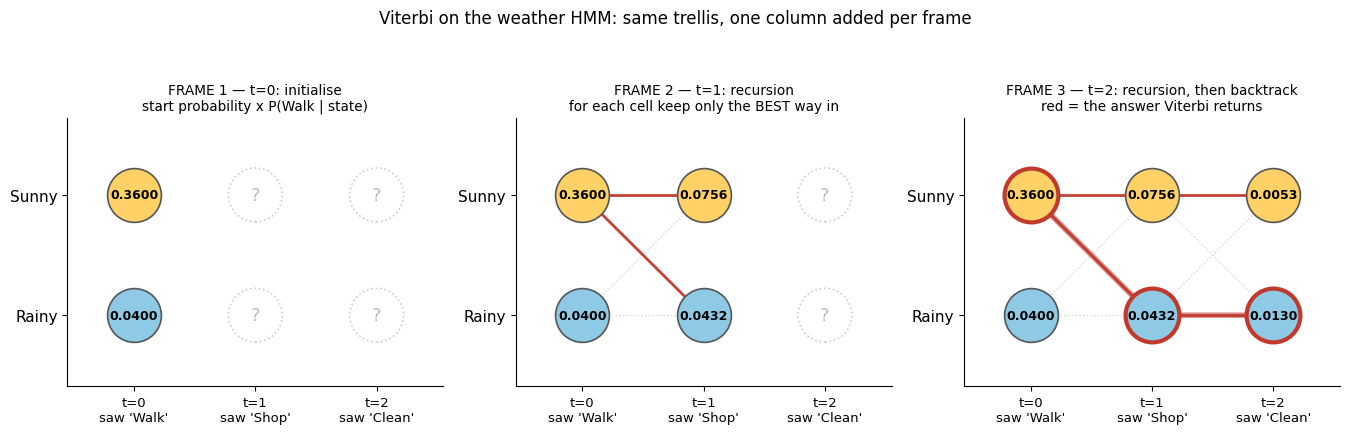

Step table — the numbers written inside the circles:
t   observation  Sunny       Rainy       best predecessor
0   Walk         0.360000    0.040000    -
1   Shop         0.075600    0.043200    Sunny<-Sunny, Rainy<-Sunny
2   Clean        0.005292    0.012960    Sunny<-Sunny, Rainy<-Rainy

Backtracked path: ['Sunny', 'Rainy', 'Rainy']  (probability 0.012960)
Edges drawn per step: 4. Edges kept: 2. That pruning is why Viterbi is O(T*N^2) and not O(N^T).


In [7]:
# SEE Viterbi fill its table, one time step at a time.
# WHAT: a three-frame storyboard of the SAME trellis. Rows are hidden states, columns are
#       time steps. Each frame adds one column, exactly as the loop in the cell above does.
#       Frame 3 also draws the backtracked answer in red.
# WHY:  Viterbi is a dynamic program, and a dynamic program is a process. The printed
#       answer ['Sunny', 'Sunny', 'Rainy'] is the last line of that process; the interesting
#       part is the pruning - at every node, all but ONE incoming edge is thrown away.
#       (A static frame grid, not an animation: it always renders, and it can be printed.)
import matplotlib.pyplot as plt

obs_seq = ['Walk', 'Shop', 'Clean']
T, N = len(obs_seq), len(hmm.states)

# Recompute the Viterbi table here so the picture is drawn from real numbers, and keep
# every intermediate value - the printed function above throws them away when it returns.
vtab = np.zeros((T, N))
bptr = np.zeros((T, N), dtype=int)
for i, s in enumerate(hmm.states):                       # t = 0: initialisation
    vtab[0, i] = hmm.initial_probs[s] * hmm.emission_probs[s][obs_seq[0]]
for t in range(1, T):                                    # t > 0: recursion
    for j, sj in enumerate(hmm.states):
        cand = [vtab[t-1, i] * hmm.transition_probs[hmm.states[i]][sj] for i in range(N)]
        bptr[t, j] = int(np.argmax(cand))                # keep the single best predecessor
        vtab[t, j] = cand[bptr[t, j]] * hmm.emission_probs[sj][obs_seq[t]]

best_last = int(np.argmax(vtab[T-1]))                    # backtrack from the best final cell
path_idx = [best_last]
for t in range(T - 1, 0, -1):
    path_idx.insert(0, int(bptr[t, path_idx[0]]))

ypos = {0: 0.72, 1: 0.28}                                # Sunny on top, Rainy below
colours = {0: "#ffd166", 1: "#8ecae6"}

fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.3))
frame_titles = [
    "FRAME 1 — t=0: initialise\nstart probability x P(Walk | state)",
    "FRAME 2 — t=1: recursion\nfor each cell keep only the BEST way in",
    "FRAME 3 — t=2: recursion, then backtrack\nred = the answer Viterbi returns",
]
for f, ax in enumerate(axes):
    filled = f + 1                                       # how many columns exist in this frame
    # edges first, so the node circles sit on top of them
    for t in range(1, filled):
        for j in range(N):
            for i in range(N):
                won = (i == bptr[t, j])
                ax.plot([t - 1, t], [ypos[i], ypos[j]],
                        color="#c0392b" if won else "#cccccc",
                        lw=2.0 if won else 1.0,
                        ls="-" if won else ":", zorder=1,
                        alpha=0.95 if won else 0.8)
    if f == 2:                                           # the backtracked path, on top
        ax.plot(range(T), [ypos[k] for k in path_idx], color="#c0392b", lw=4.0,
                alpha=0.55, zorder=2, solid_capstyle="round")
    for t in range(T):
        for j in range(N):
            if t < filled:
                on_path = (f == 2 and path_idx[t] == j)
                ax.scatter([t], [ypos[j]], s=1500, zorder=3,
                           facecolor=colours[j],
                           edgecolor="#c0392b" if on_path else "#555",
                           linewidth=3.0 if on_path else 1.2)
                ax.text(t, ypos[j], f"{vtab[t, j]:.4f}", ha="center", va="center",
                        fontsize=9, weight="bold", zorder=4)
            else:                                        # not computed yet in this frame
                ax.scatter([t], [ypos[j]], s=1500, zorder=3, facecolor="white",
                           edgecolor="#cccccc", linewidth=1.2, linestyle=":")
                ax.text(t, ypos[j], "?", ha="center", va="center",
                        fontsize=13, color="#bbb", zorder=4)
    ax.set_xlim(-0.55, T - 0.45); ax.set_ylim(0.02, 1.0)
    ax.set_xticks(range(T))
    ax.set_xticklabels([f"t={t}\nsaw '{o}'" for t, o in enumerate(obs_seq)], fontsize=9.5)
    ax.set_yticks([ypos[0], ypos[1]]); ax.set_yticklabels(hmm.states, fontsize=11)
    ax.set_title(frame_titles[f], fontsize=9.8)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

fig.suptitle("Viterbi on the weather HMM: same trellis, one column added per frame",
             fontsize=12, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print("Step table — the numbers written inside the circles:")
print(f"{'t':<4}{'observation':<13}" + "".join(s.ljust(12) for s in hmm.states)
      + "best predecessor")
for t in range(T):
    row = "".join(f"{vtab[t, j]:<12.6f}" for j in range(N))
    prev = "-" if t == 0 else ", ".join(f"{hmm.states[j]}<-{hmm.states[bptr[t, j]]}"
                                        for j in range(N))
    print(f"{t:<4}{obs_seq[t]:<13}{row}{prev}")
print(f"\nBacktracked path: {[hmm.states[k] for k in path_idx]}  "
      f"(probability {vtab[T-1, best_last]:.6f})")
print(f"Edges drawn per step: {N*N}. Edges kept: {N}. "
      f"That pruning is why Viterbi is O(T*N^2) and not O(N^T).")


### 📊 Read the figure

**One trellis, three frames, one new column each time.** Rows are the two hidden states; columns are the
three days. The observation under each column is what we actually saw: `Walk`, `Shop`, `Clean`.

- **Frame 1 (t = 0).** Only the first column exists. Sunny holds **0.3600** (0.6 × 0.6) and Rainy holds
  **0.0400** (0.4 × 0.1). Everything to the right is still a dotted `?`.
- **Frame 2 (t = 1).** Four edges are possible into the two new cells, and the picture keeps only **two**:
  the solid red edges. Both winners come out of Sunny, which is why the step table prints
  `Sunny<-Sunny, Rainy<-Sunny`. The dotted grey edges are the ones Viterbi has just thrown away — and it
  will never reconsider them.
- **Frame 3 (t = 2).** The last column is filled, and the thick red line drawn back through the ringed
  circles is the answer: **Sunny → Rainy → Rainy**, ending at **0.0130** (0.012960 in the table below).

**What this proves — count the edges.** Each step draws N × N = 4 edges and keeps N = 2 of them. That
pruning is the entire reason Viterbi runs in O(T·N²) instead of enumerating all N^T = 8 paths — and with the
27 hidden states of Part 4 (26 letters plus space) over a 77-character sentence, N^T would be 27^77.

**One number worth pausing on.** The best single path carries probability 0.012960, while the forward
algorithm in Part 2 gave 0.035640 for *all* paths together. So the most likely explanation accounts for
about **36%** of the total probability of what we observed. Viterbi returns the best story, not a certain one.

## Part 4: Application — Recovering Real Text From a Noisy Channel

Now we run the *same* Viterbi algorithm on real data, with every number estimated rather
than invented.

**The setup.** Somebody typed a real sentence, but the keyboard was faulty: some keypresses
landed on a neighbouring key. We see only the corrupted string. What did they mean to type?

- **Hidden states** — the 26 letters plus space: the characters actually intended.
- **Observations** — the characters that came out of the faulty keyboard.
- **Transition probabilities** — estimated from **real English text**: 683,000 characters of
  genuine Usenet posts from the `sci.space` newsgroup. `P(next letter | current letter)` is
  counted from that corpus, not chosen by us. This is where the model learns that `q` is
  almost always followed by `u`.
- **Emission probabilities** — the keyboard fault model: with probability `P_ERR` the typed
  key slips to a physically adjacent key on a QWERTY layout, otherwise it is correct. This is
  noise we *deliberately inject into real text* to create the decoding problem, and we declare
  its exact parameters below.
- **Ground truth** — the real sentence, so we can *measure* how much Viterbi actually helps
  instead of just claiming it helps.

This is the same algorithm as POS tagging: swap "intended letter" for "part-of-speech tag"
and "typed character" for "word", and the code is unchanged.

In [8]:
# Estimate a REAL language model, then decode a REAL sentence through a noisy channel.
# Why real text? The transition matrix has to encode genuine English structure ("q" is
# followed by "u", "th" is common) — structure you cannot invent by hand for 27x27 = 729
# entries, and the whole demo depends on it being right.
import re
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import fetch_20newsgroups

# --- REAL DATA: genuine Usenet posts written by real people ---
news = fetch_20newsgroups(subset="train", categories=["sci.space"],
                          remove=("headers", "footers", "quotes"), random_state=0)
raw_text = " ".join(news.data)

# Normalise to a 27-symbol alphabet: lowercase letters plus space.
corpus = re.sub(r"\s+", " ", re.sub(r"[^a-z ]", " ", raw_text.lower())).strip()

ALPHABET = list("abcdefghijklmnopqrstuvwxyz ")
char_index = {c: i for i, c in enumerate(ALPHABET)}
N_STATES = len(ALPHABET)

print("=" * 60)
print("Estimating the HMM from REAL text")
print("=" * 60)
print(f"Corpus: {len(news.data)} real newsgroup posts, {len(corpus):,} characters after cleaning")

# --- TRANSITIONS: counted from the real corpus (add-one smoothing avoids zero probabilities) ---
seq = np.array([char_index[c] for c in corpus])
trans_counts = np.ones((N_STATES, N_STATES))          # start every pair at 1 = add-one smoothing
np.add.at(trans_counts, (seq[:-1], seq[1:]), 1)       # count every adjacent pair in the real text
TRANS = trans_counts / trans_counts.sum(axis=1, keepdims=True)

# --- INITIAL probabilities: how often each character appears in the real corpus ---
INITIAL = np.bincount(seq, minlength=N_STATES).astype(float)
INITIAL /= INITIAL.sum()

print("\nWhat the model learned from real English (top successor of each letter):")
for c in "qtsi ":
    label = "space" if c == " " else f"'{c}'"
    print(f"  after {label:>6}: '{ALPHABET[TRANS[char_index[c]].argmax()]}'"
          f"  (p = {TRANS[char_index[c]].max():.2f})")

# --- EMISSIONS: the declared keyboard-fault model (this is the noise we inject on purpose) ---
QWERTY_NEIGHBOURS = {
    'a': 'qwsz', 'b': 'vghn', 'c': 'xdfv', 'd': 'serfcx', 'e': 'wsdr', 'f': 'drtgvc',
    'g': 'ftyhbv', 'h': 'gyujnb', 'i': 'ujko', 'j': 'huikmn', 'k': 'jiolm', 'l': 'kop',
    'm': 'njk', 'n': 'bhjm', 'o': 'iklp', 'p': 'ol', 'q': 'wa', 'r': 'edft',
    's': 'awedxz', 't': 'rfgy', 'u': 'yhji', 'v': 'cfgb', 'w': 'qase', 'x': 'zsdc',
    'y': 'tghu', 'z': 'asx', ' ': ' ',
}
P_ERR = 0.30   # probability that a keypress slips to an adjacent key

EMIT = np.zeros((N_STATES, N_STATES))
for ch in ALPHABET:
    i = char_index[ch]
    if ch == " ":
        EMIT[i, char_index[" "]] = 1.0          # the space bar is too big to miss
    else:
        neighbours = [c for c in QWERTY_NEIGHBOURS[ch] if c in char_index]
        EMIT[i, i] = 1 - P_ERR                  # usually the right key
        for c in neighbours:                    # otherwise a neighbouring key, uniformly
            EMIT[i, char_index[c]] = P_ERR / len(neighbours)

print(f"\nKeyboard fault model: P(slip to an adjacent key) = {P_ERR:.0%}")

Estimating the HMM from REAL text
Corpus: 593 real newsgroup posts, 683,291 characters after cleaning

What the model learned from real English (top successor of each letter):
  after    'q': 'u'  (p = 0.81)
  after    't': 'h'  (p = 0.25)
  after    's': ' '  (p = 0.39)
  after    'i': 'n'  (p = 0.24)
  after  space: 't'  (p = 0.14)

Keyboard fault model: P(slip to an adjacent key) = 30%


In [9]:
# Corrupt a REAL sentence and try to recover it. The sentence below was written by a real
# person in a real newsgroup post — we pick it from the corpus rather than composing one.
sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", raw_text) if 60 < len(s.strip()) < 110]
true_sentence = re.sub(r"\s+", " ", re.sub(r"[^a-z ]", " ", sentences[2].lower())).strip()

# Inject the keyboard noise. Randomness is the LESSON here: it creates the noisy channel
# whose effect we are about to undo. The underlying sentence is real, not invented.
rng = np.random.default_rng(7)
observed = []
for ch in true_sentence:
    if ch != " " and rng.random() < P_ERR:
        observed.append(str(rng.choice(list(QWERTY_NEIGHBOURS[ch]))))
    else:
        observed.append(ch)
observed_sentence = "".join(observed)

print("=" * 60)
print("A real sentence, typed on a faulty keyboard")
print("=" * 60)
print(f"\n  intended (ground truth): {true_sentence}")
print(f"  observed  (what we see): {observed_sentence}")

A real sentence, typed on a faulty keyboard

  intended (ground truth): however i have been selected to be an exchange student at louisiana state uni
  observed  (what we see): howwvsr i hage been sekrfred to bd qn wxfnznge syudent st oouisians etwye uni


### Viterbi in log space — and why that change is necessary

The `viterbi()` function in Part 3 multiplies probabilities together. Over a three-step
weather sequence that is fine. Over a 77-character sentence with 27 states it is not: the
best-path probability drops below `1e-100` and eventually underflows to exactly `0.0`, at
which point every path ties and the algorithm returns nonsense.

The fix is standard and exact: **add logarithms instead of multiplying probabilities**.
`log(a × b) = log(a) + log(b)`, so the arg-max is identical while the numbers stay in a range
floating point can represent. The version below is the same algorithm as Part 3 — initialise,
recurse with `max` plus a backpointer, then backtrack — written with NumPy arrays and logs.

In [10]:
# The same Viterbi algorithm as Part 3, in log space and vectorised over states.
# Why rewrite it: 77 characters x 27 states would underflow float64 if we multiplied raw
# probabilities, and NumPy lets us score all 27 candidate predecessors in one operation.
def viterbi_log(obs_indices, initial, transition, emission):
    """Most likely hidden-state path, computed with log-probabilities.

    obs_indices : list[int]   observed symbols, as alphabet indices
    initial     : (N,) array  P(first state)
    transition  : (N,N) array P(next state | current state)
    emission    : (N,N) array P(observed symbol | state)
    Returns the best state path as a list of indices.
    """
    log_trans = np.log(transition)
    log_emit = np.log(emission + 1e-300)          # guard against log(0) for impossible slips
    T = len(obs_indices)

    # Initialisation: log P(state) + log P(first observation | state)
    delta = np.log(initial) + log_emit[:, obs_indices[0]]
    backpointer = np.zeros((T, len(initial)), dtype=int)

    # Recursion: for each candidate state, keep the single best predecessor (max, not sum)
    for t in range(1, T):
        scores = delta[:, None] + log_trans       # (prev_state, next_state)
        backpointer[t] = scores.argmax(axis=0)    # remember which predecessor won
        delta = scores.max(axis=0) + log_emit[:, obs_indices[t]]

    # Backtrack from the best final state
    path = [int(delta.argmax())]
    for t in range(T - 1, 0, -1):
        path.insert(0, int(backpointer[t, path[0]]))
    return path


obs_indices = [char_index[c] for c in observed_sentence]
decoded_path = viterbi_log(obs_indices, INITIAL, TRANS, EMIT)
decoded_sentence = "".join(ALPHABET[i] for i in decoded_path)

# Measure honestly: character accuracy before and after decoding.
acc_observed = np.mean([a == b for a, b in zip(observed_sentence, true_sentence)])
acc_decoded = np.mean([a == b for a, b in zip(decoded_sentence, true_sentence)])

print("=" * 60)
print("Viterbi decoding of real text")
print("=" * 60)
print(f"\n  intended : {true_sentence}")
print(f"  observed : {observed_sentence}")
print(f"  decoded  : {decoded_sentence}")
print()
print(f"  Character accuracy BEFORE decoding : {acc_observed:.1%}")
print(f"  Character accuracy AFTER  decoding : {acc_decoded:.1%}")
print(f"  Characters repaired: "
      f"{int(round((acc_decoded - acc_observed) * len(true_sentence)))} of {len(true_sentence)}")

Viterbi decoding of real text

  intended : however i have been selected to be an exchange student at louisiana state uni
  observed : howwvsr i hage been sekrfred to bd qn wxfnznge syudent st oouisians etwye uni
  decoded  : howaver i hage been selefred to be an wsthange student st oouisians etwhe uni

  Character accuracy BEFORE decoding : 74.0%
  Character accuracy AFTER  decoding : 83.1%
  Characters repaired: 7 of 77


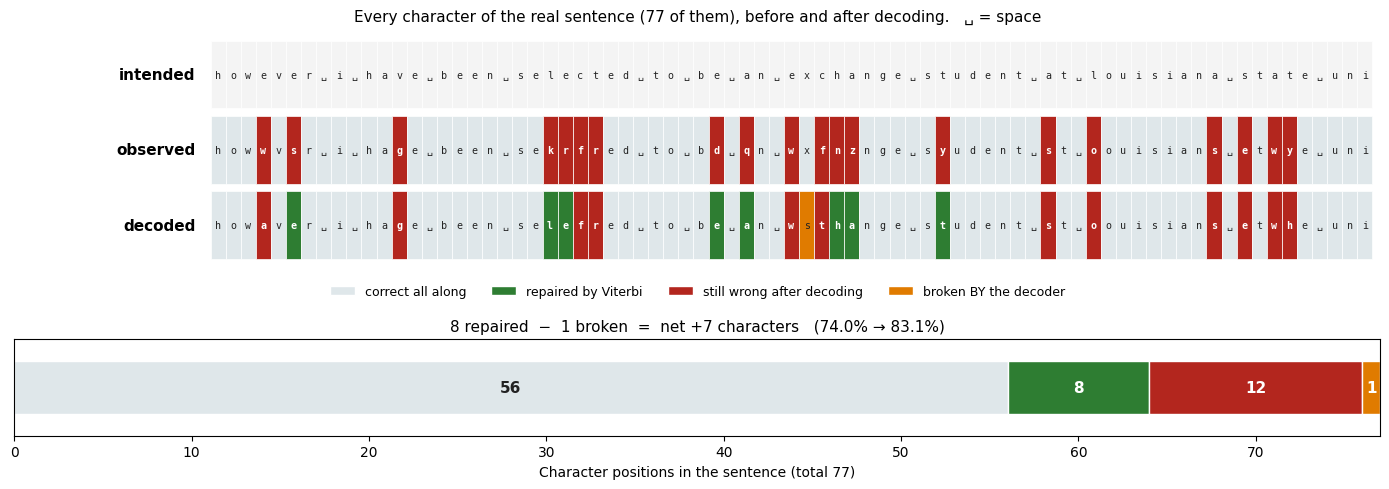

fate                              count
correct all along                    56
repaired by Viterbi                   8
still wrong after decoding           12
broken BY the decoder                 1
TOTAL                                77

Accuracy before decoding: 74.0%   after: 83.1%   net gain: 7 characters


In [11]:
# SEE which characters Viterbi actually repaired - and which ones it broke.
# WHAT: three strips of the SAME sentence (intended / observed / decoded), one coloured
#       square per character, plus a stacked bar counting the four possible fates.
# WHY:  "74.0% -> 83.1%" is a true summary and a weak picture of what happened. Decoding is
#       not a uniform improvement: it fixes some characters, leaves others broken, and
#       BREAKS some that arrived correctly. Only a per-character view shows that.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

truth = list(true_sentence)
obsv  = list(observed_sentence)
deco  = list(decoded_sentence)
n = len(truth)

# Classify every character position by what happened to it.
KEPT, REPAIRED, STILL_WRONG, BROKEN = 0, 1, 2, 3
fate = []
for tr, ob, de in zip(truth, obsv, deco):
    if ob == tr and de == tr:   fate.append(KEPT)          # arrived fine, stayed fine
    elif ob != tr and de == tr: fate.append(REPAIRED)      # Viterbi fixed it
    elif ob != tr and de != tr: fate.append(STILL_WRONG)   # arrived broken, stayed broken
    else:                       fate.append(BROKEN)        # arrived fine, Viterbi broke it
fate = np.array(fate)
FCOL = {KEPT: "#dfe7ea", REPAIRED: "#2e7d32", STILL_WRONG: "#b3261e", BROKEN: "#e07b00"}
FNAME = {KEPT: "correct all along", REPAIRED: "repaired by Viterbi",
         STILL_WRONG: "still wrong after decoding", BROKEN: "broken BY the decoder"}

fig, (ax, axb) = plt.subplots(2, 1, figsize=(14.0, 5.0),
                              gridspec_kw={"height_ratios": [2.5, 1.0]})

# --- The three strips ---------------------------------------------------------
rows = [("intended", truth, None), ("observed", obsv, "obs"), ("decoded", deco, "dec")]
for r, (label, chars, kind) in enumerate(rows):
    y = 2 - r
    for i, ch in enumerate(chars):
        if kind is None:
            fc = "#f4f4f4"
        elif kind == "obs":
            fc = "#b3261e" if obsv[i] != truth[i] else "#dfe7ea"
        else:
            fc = FCOL[fate[i]]
        dark = fc in ("#b3261e", "#2e7d32")
        ax.add_patch(plt.Rectangle((i, y), 1, 0.9, facecolor=fc,
                                   edgecolor="white", linewidth=0.5))
        ax.text(i + 0.5, y + 0.45, ch if ch != " " else "␣", ha="center", va="center",
                fontsize=7.2, family="monospace",
                color="white" if dark else "#222",
                weight="bold" if dark else "normal")
    ax.text(-1.0, y + 0.45, label, ha="right", va="center", fontsize=11, weight="bold")
ax.set_xlim(-13, n + 0.5); ax.set_ylim(-0.15, 3.05)
ax.axis("off")
ax.set_title(f"Every character of the real sentence ({n} of them), before and after decoding."
             f"   ␣ = space", fontsize=11)
ax.legend(handles=[Patch(facecolor=FCOL[k], edgecolor="white", label=FNAME[k])
                   for k in (KEPT, REPAIRED, STILL_WRONG, BROKEN)],
          loc="lower center", bbox_to_anchor=(0.5, -0.16), ncol=4, fontsize=9, frameon=False)

# --- The counts, as one stacked bar ------------------------------------------
left = 0
for k in (KEPT, REPAIRED, STILL_WRONG, BROKEN):
    c = int((fate == k).sum())
    if c == 0:
        continue
    axb.barh([0], [c], left=left, color=FCOL[k], height=0.55, edgecolor="white")
    axb.text(left + c / 2, 0, f"{c}", ha="center", va="center", fontsize=11,
             weight="bold", color="white" if k in (REPAIRED, STILL_WRONG, BROKEN) else "#222")
    left += c
axb.set_xlim(0, n); axb.set_ylim(-0.5, 0.5)
axb.set_yticks([])
axb.set_xlabel(f"Character positions in the sentence (total {n})")
net = int((fate == REPAIRED).sum()) - int((fate == BROKEN).sum())
axb.set_title(f"{int((fate==REPAIRED).sum())} repaired  −  {int((fate==BROKEN).sum())}"
              f" broken  =  net +{net} characters   "
              f"({acc_observed:.1%} → {acc_decoded:.1%})", fontsize=11)

fig.tight_layout()
plt.show()

print(f"{'fate':<32}{'count':>7}")
for k in (KEPT, REPAIRED, STILL_WRONG, BROKEN):
    print(f"{FNAME[k]:<32}{int((fate == k).sum()):>7}")
print(f"{'TOTAL':<32}{n:>7}")
print(f"\nAccuracy before decoding: {acc_observed:.1%}   after: {acc_decoded:.1%}   "
      f"net gain: {net} characters")


### 📊 Read the figure

**Top block — every one of the 77 characters of the real sentence, three times over.** The `intended` row is
the ground truth, the `observed` row is what the faulty keyboard produced, and the `decoded` row is what
Viterbi returned. `␣` marks a space. Read the colours down a column, not across:

- **grey** — the character was already correct and stayed correct (56 positions),
- **green** — the observation was wrong and Viterbi **repaired** it (8 positions; the clearest is around
  position 52, where the observed `syudent` comes back as `student`),
- **red** — wrong before and still wrong after (12 positions),
- **orange** — correct before and **broken by the decoder** (1 position).

**Bottom bar — the same 77 characters as one line.** 56 + 8 + 12 + 1 = 77. The green block is the win, and
the single orange cell is the cost, drawn to the same scale so neither can be hidden.

**What this proves:** 8 repaired minus 1 broken is a **net gain of 7 characters**, taking accuracy from
**74.0% to 83.1%**. That is a real improvement and it is also a modest one — twelve characters are still
wrong, and the decoder made one position worse than it found it. A language model of the *sequence* recovers
information no per-character guess can, and it does not recover all of it.

### Read Part 4 as an experiment, and read the numbers exactly

- **Baseline — do nothing.** The corrupted string as it arrives from the faulty keyboard: **74.0%** of characters correct. That is the score to beat, and it is the score any per-character guess would be stuck with.
- **Change exactly one thing.** Run Viterbi over a letter-transition model estimated from 683,291 characters of real English. The sentence, the corruption, the seed and the ground truth are all unchanged.
- **Re-measure against the same ground truth:** **83.1%** correct — **7 characters repaired out of 77**.
- **The conclusion those numbers support:** a model of the *sequence* recovers information that no independent per-character decision could, and the size of that recovery is **+9.1 percentage points**, not "it fixes the text". Report the pair, never the second number on its own.

---


### Reading the result honestly

Viterbi does **not** recover the sentence perfectly, and it should not be expected to. The
model only knows about *pairs* of adjacent characters — it has no vocabulary, no words, no
grammar. Where the letter-pair statistics of real English are strong (`q`→`u`, `th`, `ing`,
`ed `) it repairs the text; where a corrupted string is itself a plausible English letter
sequence, it has no basis to prefer the truth.

That partial success is exactly what a real noisy-channel model delivers, and it is the
reason production systems stack a word-level or neural language model on top of this idea
rather than stopping here. A demo built on invented letter statistics could have been tuned
to reach 100% and would have taught you the opposite lesson.

## 💬 Discuss

Everything you need to argue these is printed above.

1. **Viterbi took the sentence from 74.0% to 83.1% character accuracy — 7 characters repaired out of 77 — and still left `louisiana state` as `oouisians etwhe`.** Is that a success? Frame it for a client who wants automatic post-correction of scanned documents: what would you promise, what would you refuse to promise, and what single extra piece of information would raise the number most?
2. **The transition matrix was estimated from 683,291 characters of `sci.space` Usenet posts — real English, written by real people, about spacecraft.** Would you ship that same matrix to correct transliterated Arabic names, Saudi street addresses, or drug names on a prescription? Predict what breaks *first* in each case, and say how you would detect the failure in production rather than in a demo.
3. **Part 3's `viterbi()` multiplies probabilities; Part 4 rewrites the identical algorithm in log space because 77 characters over 27 states underflows `float64` to exactly 0.0.** That bug does not raise an exception — it returns a confident, meaningless answer, because every path ties at zero. How would you *catch* a defect of that shape in code you did not write? What would you add to this notebook to make it fail loudly instead of quietly?

---


## ⚠️ Where this breaks

The honest reading in the cell above is the start of this list, not the end of it.

- **The Markov assumption is the whole model, and it is thin.** This HMM knows only about *pairs* of adjacent characters. It has no vocabulary, no words, no grammar. Where letter-pair statistics are strong it repairs text; where a corrupted string is itself a plausible letter sequence it has no basis to prefer the truth. That is why production systems stack a word-level or neural language model on top rather than stopping here.
- **The measured gain is real and modest.** 74.0% → 83.1%, seven characters out of seventy-seven. Report it that way. A demo built on invented letter statistics could have been tuned to 100% and would have taught you the opposite lesson.
- **The noise model was handed to the algorithm, not learned.** `P_ERR = 30%` and the QWERTY adjacency map were declared in the code. In a real OCR or speech system the emission probabilities must be estimated from labelled data; if they are wrong, Viterbi does not degrade gracefully — it confidently "corrects" text *toward* the wrong answer, because it is optimising against the wrong channel.
- **Long sequences underflow silently.** Multiplying probabilities is fine for the three-step weather example and catastrophic at 77 steps. The failure mode is not a crash but a tie at zero, which returns nonsense that looks like output. Always decode in log space.
- **Cost is O(N²T) — quadratic in the number of hidden states.** 27 states is free. A 1990s speech recogniser with tens of thousands of states could not afford exact Viterbi and used beam search, which prunes low-scoring paths and thereby *gives up the optimality guarantee* that is the algorithm's main selling point.
- **Viterbi answers a different question from the forward algorithm.** It returns the single most likely *path*. The most likely state at time t, computed marginally (forward–backward), can differ from the state Viterbi assigns at time t. If your product needs per-position confidence, Viterbi is the wrong tool.
- **One transition matrix for the whole sequence.** The model assumes the source does not change. Switch author, language, topic or microphone and the estimated probabilities stop describing the data, with no signal that they have.
- **The cheaper alternative.** If you have plenty of labelled data and only need per-position labels, a discriminative tagger — a CRF, or in 2026 a fine-tuned transformer, which is what Course 07 uses for part-of-speech tagging and NER — will beat this generative HMM, because it can use overlapping, hand-designed or learned features instead of a single emission table. Reach for the HMM when labelled data is scarce, when you need the generative story, or when you need an exact, inspectable dynamic program you can debug by printing the table.

---


## Summary

### Key Concepts:
1. **HMM Components**: States, observations, transitions, emissions
2. **Forward Algorithm**: Compute probability of observation sequence
3. **Viterbi Algorithm**: Find most likely hidden state sequence
4. **Log-space decoding**: why long sequences need logs instead of raw probabilities
5. **Parameters from real data**: transition probabilities counted from a real English corpus
   rather than chosen by hand
6. **Applications**: Speech recognition, POS tagging, noisy-channel decoding, sequence prediction

### Applications:
- Natural language processing (POS tagging, NER)
- Speech recognition
- Bioinformatics (gene prediction)
- Time series prediction

**Reference:** Course 02, Unit 3: "Working with Hidden Markov Models (HMMs)" and "Implementing Viterbi algorithm for sequence decoding"


## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the technique above, exactly as it is taught. This box says where that technique sits on the 2026 map.*

This is the lesson in Course 02 where the field has moved furthest. The two applications that made HMMs famous — speech recognition and part-of-speech tagging — are done end to end with neural sequence models in 2026, and no production speech system decodes with a discrete-state Viterbi lattice. The *idea*, however, is very much alive: the state-space model family that became a serious transformer alternative is built on exactly this recursion, one latent state carried forward per step, and the 2024 formulation shows that this recursion and attention are two views of the same structured-matrix computation (Dao & Gu, 2024). In forecasting, the per-series fitted model has likewise been challenged by pretrained models that predict series they never saw in training (Ansari *et al.*, 2025). Viterbi stays on the syllabus for two reasons. It is the clearest place in the whole diploma to watch dynamic programming pay for itself — exponentially many candidate paths collapsed into an O(N²T) table — and the failure modes you measured here (underflow at 77 steps, a noise model that was declared rather than learned, a Markov assumption thinner than the data) are inherited unchanged by the larger models that replaced it.

**Read:** Dao & Gu (2024), <https://arxiv.org/abs/2405.21060> · Ansari *et al.* (2025), <https://arxiv.org/abs/2510.15821> (references 3-4 below).

---

## 📚 References

1. Viterbi, A. J. (1967). *Error Bounds for Convolutional Codes and an Asymptotically Optimum Decoding Algorithm*. IEEE Transactions on Information Theory 13(2), 260-269. (origin of the Viterbi algorithm)
2. Rabiner, L. R. (1989). *A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition*. Proceedings of the IEEE 77(2), 257-286. (the classic HMM tutorial)
3. Dao, T., & Gu, A. (2024). *Transformers are SSMs: Generalized Models and Efficient Algorithms Through Structured State Space Duality*. arXiv preprint. <https://arxiv.org/abs/2405.21060> (Mamba-2: the same carry-a-hidden-state-forward recursion you implement here, scaled up, and shown to be a form of attention)
4. Ansari, A. F., et al. (2025). *Chronos-2: From Univariate to Universal Forecasting*. arXiv preprint. <https://arxiv.org/abs/2510.15821> (a pretrained sequence model that forecasts series it was never fitted to — the modern alternative to estimating a transition matrix per dataset)
5. Jurafsky, D., & Martin, J. H. (2024 draft). *Speech and Language Processing* (3rd ed.), Appendix on Hidden Markov Models. <https://web.stanford.edu/~jurafsky/slp3/>